## RiverCast: Forecasting Marikina River Level using Seasonal Trend Decomposition and Transformer

### Import Dataset and Libraries

In [139]:
import time
import calendar
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from skimage.measure import block_reduce
from sklearn.metrics import mean_absolute_error

import copy
import math
import torch
import torch.nn as nn

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')  # configure GPU utilization

In [140]:
df = pd.read_csv('riverlevel.csv')

### Prepare the Dataset

To make sure that our data types are suited for learning, the researchers converted 'Month', 'Day', and 'Year' columns to timestamps; converted all numerical values into double precision floating numbers; filled in NULL values; and resampled the data to 24-hour intervals.

In [141]:
# convert month name to integer
month_dict = dict((v, k) for k, v in enumerate(calendar.month_name))
df['Month'] = df['Month'].map(month_dict)

# create datetime column
df[['Year', 'Month', 'Day', 'Hour']] = df[['Year', 'Month', 'Day', 'Hour']].astype(int)
df['Hour'] = df['Hour'].apply(lambda x: x if x < 24 else 0)

# convert year, month, day, and hour columns into timestamp
df['Datetime'] = df[['Year', 'Month', 'Day', 'Hour']].apply(lambda row: datetime(row['Year'], row['Month'], row['Day'], row['Hour']).isoformat(), axis=1)
df["Datetime"] = pd.to_datetime(df["Datetime"], format='ISO8601')

# assign timestamps as the data frame index
df.index = df["Datetime"]
df = df.drop(['Datetime'], axis=1)

# select the parameters
df = df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'RF-Intensity', 'RF-Intensity.1', 'Precipitation', 'Humidity', 'Temperature']] 
df = df.astype(np.float64)  # convert parameters into a double precision floating number

# fill in missing values using linear interpolation
df = df.interpolate(method='linear', limit_direction='forward')
df = df.resample('24H').max()  # resample dataset using the max value for each 24-hours

df.head(10)  # display data frame

,Waterlevel,Waterlevel.1,Waterlevel.2,RF-Intensity,RF-Intensity.1,Precipitation,Humidity,Temperature
Datetime,,,,,,,,
2012-01-01,15.94,12.53,21.97,0.0,0.0,0.08,18.01,28.69
2012-01-02,15.86,12.52,21.96,0.0,4.0,0.41,17.88,28.08
2012-01-03,15.94,12.51,21.94,7.0,4.0,1.64,17.88,27.39
2012-01-04,16.00,12.50,22.03,0.0,0.0,1.41,17.82,27.20
2012-01-05,15.85,12.49,22.01,0.0,0.0,0.35,16.36,26.10
2012-01-06,15.84,12.49,21.96,0.0,4.0,1.41,17.15,27.24
2012-01-07,15.86,12.48,21.94,1.0,0.0,1.50,18.49,27.40
2012-01-08,16.01,12.46,22.09,7.0,5.0,1.99,18.31,25.32
2012-01-09,15.88,12.45,22.10,0.0,1.0,0.65,17.82,27.19


### Clean Dataset

The researchers reduced the outliers in the dataset using moving average smoothing. Note the we only reduced the outliers but not completely remove them to enable the model learn about flooding incidents.

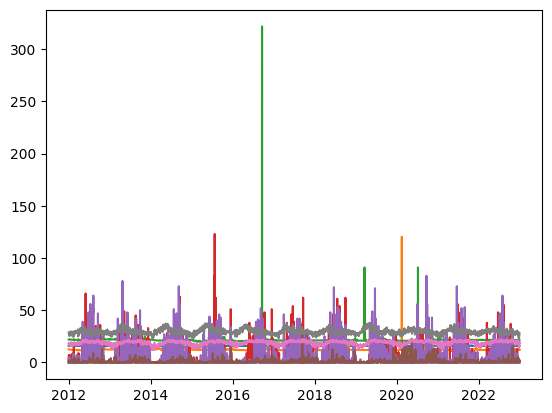

In [142]:
# visualize the current dataset
plt.plot(df)
plt.show()

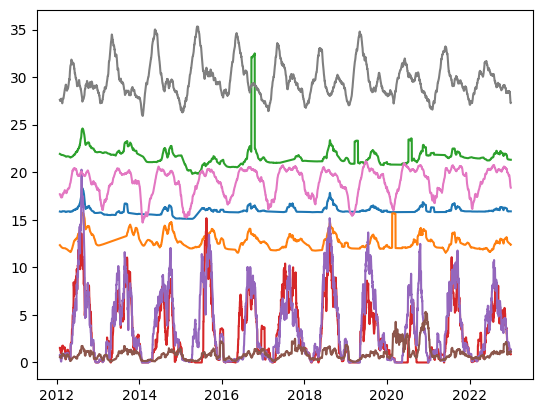

In [143]:
df = df.rolling(30).mean().dropna()  # perform moving average smoothing

# visualize dataset with reduced outliers
plt.plot(df)
plt.show()

### Seasonal Trend Decomposition

Seasonal Trend Decomposition is a statistical technique used to extract the seasonal component, the trend component, and the residual component in the time-series dataset. This decomposition helps to identify underlying patterns thus producing reliable forecasts. The seasonal component represents the regular, repeating patterns or cycles in the time series data while the trend component represents the long-term, underlying direction in the time series data. On the other hand, the residual component represents the unexplained variation in the time series data after removing the seasonal and trend components.

#### River Levels

To avoid confusion, the researchers separated seasonal trend decomposition of river level parameters from weather parameters. 

Extracting the seasonal component is done by subtracting the trend component from the original data. To find the trend component in the dataset, the researchers use the polyfit method to find the polynomial function that fits to the time index and the seasonally-adjusted time series data. Then, by applying the polynomial function to the time index, the trend component is extracted.

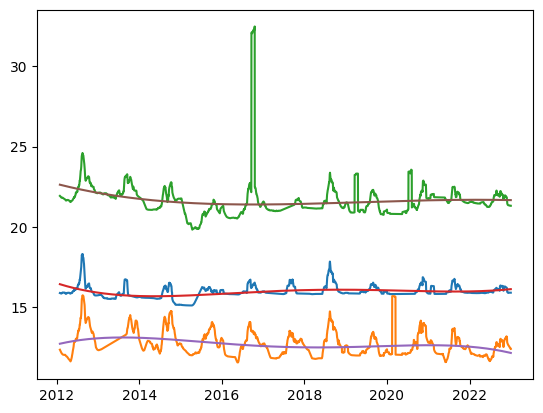

In [144]:
order = 4
record_len = len(df)

river_df = df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2']]

waterlevel_coef = np.polyfit(np.arange(record_len), river_df['Waterlevel'].values.ravel(), order)
waterlevel1_coef = np.polyfit(np.arange(record_len), river_df['Waterlevel.1'].values.ravel(), order)
waterlevel2_coef = np.polyfit(np.arange(record_len), river_df['Waterlevel.2'].values.ravel(), order)

poly_mdl = np.poly1d(waterlevel_coef)
poly_mdl1 = np.poly1d(waterlevel1_coef)
poly_mdl2 = np.poly1d(waterlevel2_coef)

trend_components = pd.DataFrame({
        'Waterlevel': poly_mdl(np.arange(record_len)),
        'Waterlevel.1': poly_mdl1(np.arange(record_len)),
        'Waterlevel.2': poly_mdl2(np.arange(record_len))
    }, index=df.index)

plt.plot(river_df)
plt.plot(trend_components)
plt.show()

The seasonal component is extracted by subtracting the found trend components from the original data.

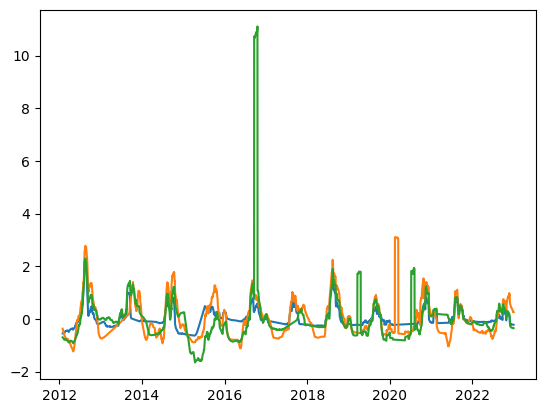

In [145]:
detrended_df = river_df - trend_components

plt.plot(detrended_df)
plt.show()

To further simplify the seasonal component, the researchers extracted the yearly pattern (12 months) of the data. As we can observe, the river levels are at peek during August to October.

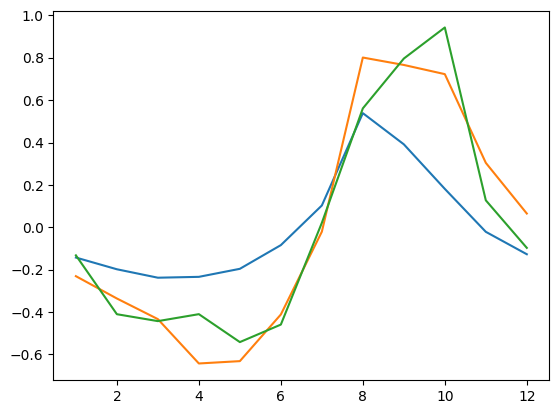

In [146]:
seasonal_components = detrended_df.groupby(by=detrended_df.index.month).mean()

plt.plot(seasonal_components)
plt.show()

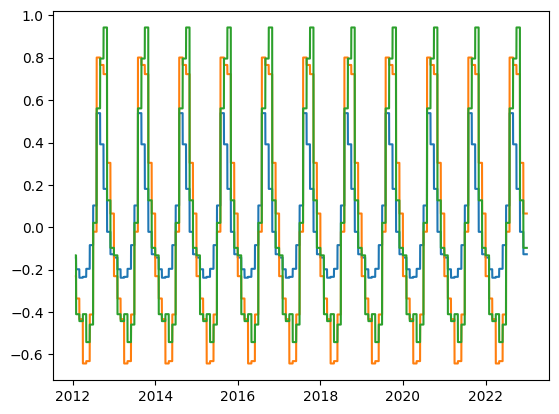

In [147]:
# Copy the extracted yearly pattern across all years in the dataset
seasonal_df = river_df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2']]
for col in seasonal_df.columns:
    for i in seasonal_components.index:
        seasonal_df.loc[seasonal_df.index.month == i, col] = seasonal_components.loc[i, col]

plt.plot(seasonal_df)
plt.show()

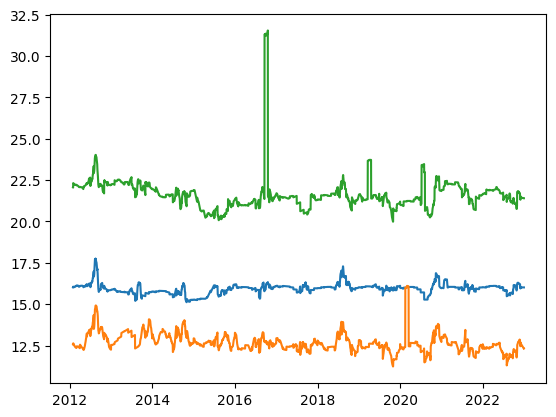

In [148]:
# remove the seasonal components from the original data to double check the trend component
deseasonal_df = river_df - seasonal_df

plt.plot(deseasonal_df)
plt.show()

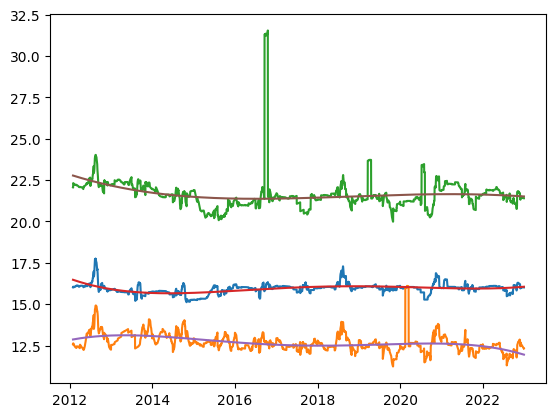

In [149]:
# extract the trend component again using the detrend and deseasonal data
waterlevel_coef = np.polyfit(np.arange(record_len), deseasonal_df['Waterlevel'].values.ravel(), order)
waterlevel1_coef = np.polyfit(np.arange(record_len), deseasonal_df['Waterlevel.1'].values.ravel(), order)
waterlevel2_coef = np.polyfit(np.arange(record_len), deseasonal_df['Waterlevel.2'].values.ravel(), order)

poly_mdl = np.poly1d(waterlevel_coef)
poly_mdl1 = np.poly1d(waterlevel1_coef)
poly_mdl2 = np.poly1d(waterlevel2_coef)

trend_df = pd.DataFrame({
        'Waterlevel': poly_mdl(np.arange(record_len)),
        'Waterlevel.1': poly_mdl1(np.arange(record_len)),
        'Waterlevel.2': poly_mdl2(np.arange(record_len))
    }, index=df.index)

plt.plot(deseasonal_df)
plt.plot(trend_df)
plt.show()

Lastly, the researchers added the seasonal component and the trend component. Notice that the residual component is not present because as mentioned earlier, residual components are the irregularities in the data. By adding only the seasonal and trend component, the researchers eliminated the unexplained variations, noise, and any irregularities that are not accounted for river level forecasting. 

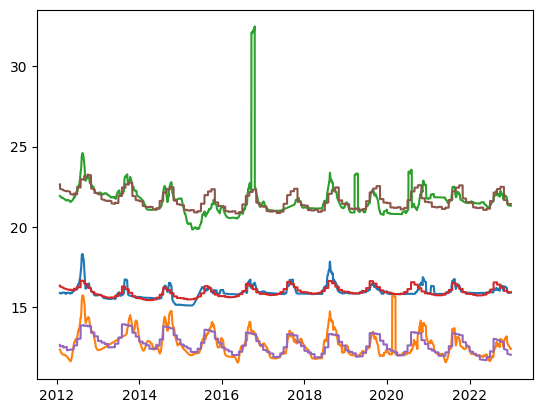

In [150]:
river_df = seasonal_df + trend_df

plt.plot(df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2']])
plt.plot(river_df)
plt.show()

#### River Levels

To avoid confusion, the researchers separated seasonal trend decomposition of weather parameters from river level parameters. The following process are the same with the river level seasonal trend decomposition explained above.

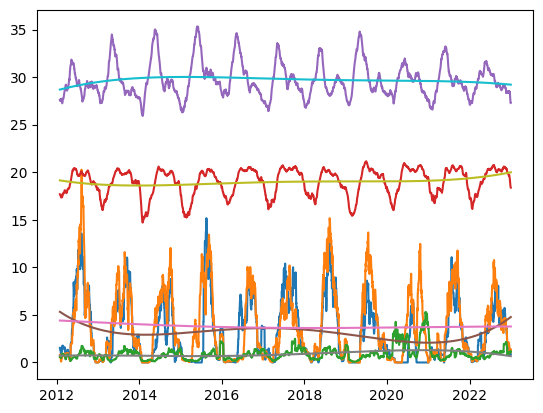

In [151]:
order = 4
record_len = len(df)

weather_df = df[['RF-Intensity', 'RF-Intensity.1', 'Precipitation', 'Humidity', 'Temperature']]

rain_coef = np.polyfit(np.arange(record_len), weather_df['RF-Intensity'].values.ravel(), order)
rain1_coef = np.polyfit(np.arange(record_len), weather_df['RF-Intensity.1'].values.ravel(), order)
precp_coef = np.polyfit(np.arange(record_len), weather_df['Precipitation'].values.ravel(), order)
temp_coef = np.polyfit(np.arange(record_len), weather_df['Humidity'].values.ravel(), order)
humid_coef = np.polyfit(np.arange(record_len), weather_df['Temperature'].values.ravel(), order)

poly_rain = np.poly1d(rain_coef)
poly_rain1 = np.poly1d(rain1_coef)
poly_precp = np.poly1d(precp_coef)
poly_temp = np.poly1d(temp_coef)
poly_humid = np.poly1d(humid_coef)

trend_components = pd.DataFrame({
        'RF-Intensity': poly_rain(np.arange(record_len)),
        'RF-Intensity.1': poly_rain1(np.arange(record_len)),
        'Precipitation': poly_precp(np.arange(record_len)),
        'Humidity': poly_temp(np.arange(record_len)),
        'Temperature': poly_humid(np.arange(record_len))
    }, index=df.index)

plt.plot(weather_df)
plt.plot(trend_components)
plt.show()

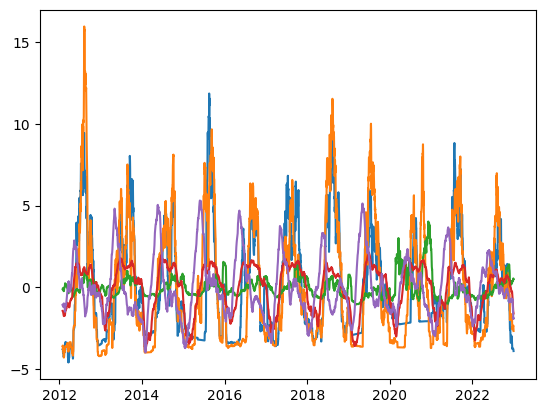

In [152]:
detrended_df = weather_df - trend_components

plt.plot(detrended_df)
plt.show()

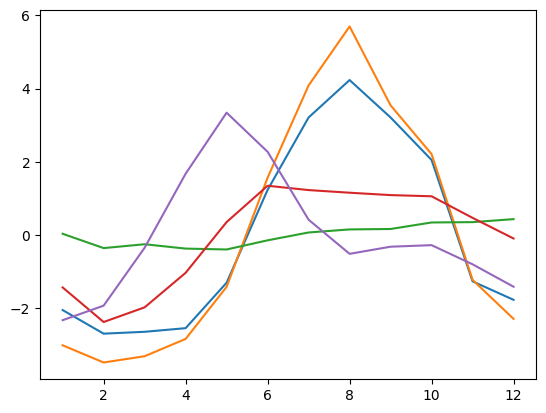

In [153]:
seasonal_components = detrended_df.groupby(by=detrended_df.index.month).mean()

plt.plot(seasonal_components)
plt.show()

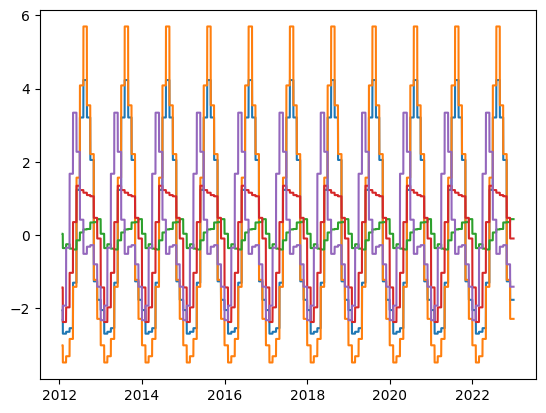

In [154]:
seasonal_df = weather_df[['RF-Intensity', 'RF-Intensity.1', 'Precipitation', 'Humidity', 'Temperature']]
for col in seasonal_df.columns:
    for i in seasonal_components.index:
        seasonal_df.loc[seasonal_df.index.month == i, col] = seasonal_components.loc[i, col]

plt.plot(seasonal_df)
plt.show()

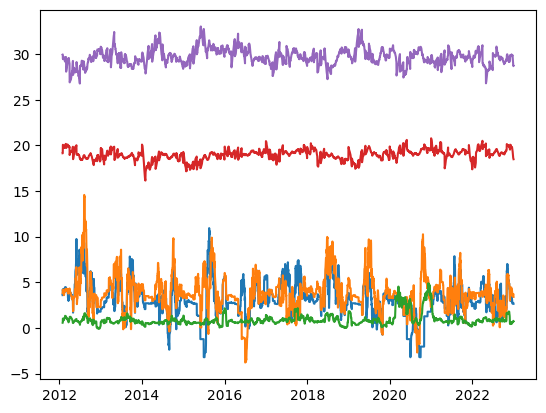

In [155]:
deseasonal_df = weather_df - seasonal_df

plt.plot(deseasonal_df)
plt.show()

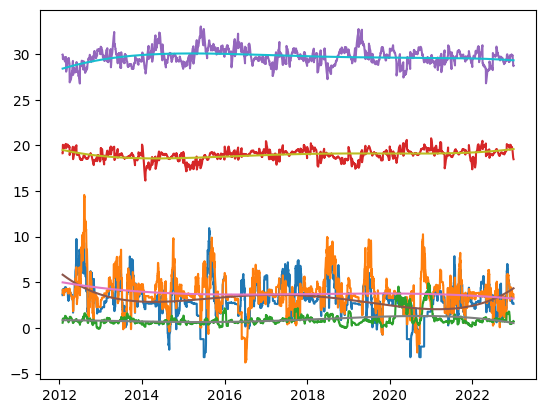

In [156]:
rain_coef = np.polyfit(np.arange(record_len), deseasonal_df['RF-Intensity'].values.ravel(), order)
rain1_coef = np.polyfit(np.arange(record_len), deseasonal_df['RF-Intensity.1'].values.ravel(), order)
precp_coef = np.polyfit(np.arange(record_len), deseasonal_df['Precipitation'].values.ravel(), order)
temp_coef = np.polyfit(np.arange(record_len), deseasonal_df['Humidity'].values.ravel(), order)
humid_coef = np.polyfit(np.arange(record_len), deseasonal_df['Temperature'].values.ravel(), order)

poly_rain = np.poly1d(rain_coef)
poly_rain1 = np.poly1d(rain1_coef)
poly_precp = np.poly1d(precp_coef)
poly_temp = np.poly1d(temp_coef)
poly_humid = np.poly1d(humid_coef)

trend_df = pd.DataFrame({
        'RF-Intensity': poly_rain(np.arange(record_len)),
        'RF-Intensity.1': poly_rain1(np.arange(record_len)),
        'Precipitation': poly_precp(np.arange(record_len)),
        'Humidity': poly_temp(np.arange(record_len)),
        'Temperature': poly_humid(np.arange(record_len))
    }, index=df.index)

plt.plot(deseasonal_df)
plt.plot(trend_df)
plt.show()

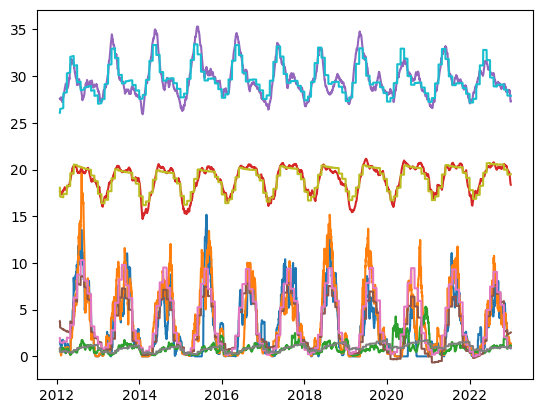

In [157]:
weather_df = seasonal_df + trend_df

plt.plot(df[['RF-Intensity', 'RF-Intensity.1', 'Precipitation', 'Humidity', 'Temperature']])
plt.plot(weather_df)
plt.show()

The sum of the extracted seasonal and trend components will serve as the model's input while the original future values will server as labels. In this way, the forecasting model can focus on temporal patterns and avoid over fitting.

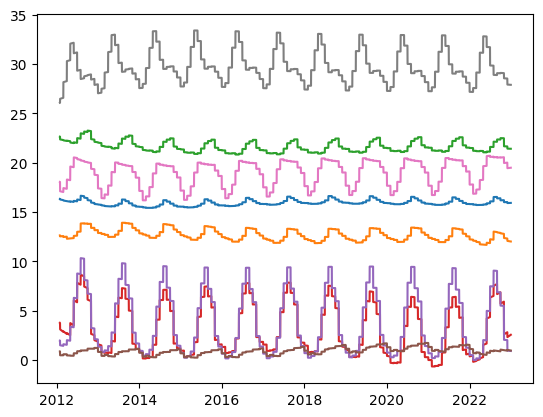

In [158]:
decomposed_df = pd.concat([river_df, weather_df], axis=1)

plt.plot(decomposed_df)
plt.show()

### Normalize Dataset

In [159]:
scaler = MinMaxScaler()
scaler.fit(df)

original_data = scaler.transform(df)
decomposed_data = scaler.transform(decomposed_df)

print(original_data.shape)
print(decomposed_data.shape)

(3989, 8)
(3989, 8)


### Prepare Dataset Batches

Time-series data from January 2012 to December 2019 will serve as the training dataset while the data from January 2020 to December 2022 will serve as the test dataset.

In [160]:
train_in = decomposed_data[:2922]
train_out = original_data[:2922]

print(train_in.shape)
print(train_out.shape)

test_in = decomposed_data[-1095:]
test_out = original_data[-1095:]

print(test_in.shape)
print(test_out.shape)

(2922, 8)
(2922, 8)
(1095, 8)
(1095, 8)


In [161]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, outputs, seq_len):
        self.inputs = inputs
        self.outputs = outputs
        self.seq_len = seq_len
        
    def __getitem__(self, index):
        in_start = index
        in_end = in_start + self.seq_len
        out_start = index + int(self.seq_len / 2)
        out_end = out_start + self.seq_len
        
        inputs = self.inputs[in_start:in_end]
        labels = self.outputs[out_start:out_end]
        
        return inputs, labels
    
    def __len__(self):
        return len(self.inputs) - (int(self.seq_len / 2) * 3) + 1

In [162]:
BATCH_SIZE = 64
SEQ_LEN = 730

train_dataset = TimeSeriesDataset(train_in, train_out, seq_len=SEQ_LEN)
test_dataset = TimeSeriesDataset(test_in, test_out, seq_len=SEQ_LEN)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(len(train_dataloader))
print(len(test_dataloader))

29
1


### Build the Model

In [163]:
PRED_SIZE = 8
D_MODEL = 8
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 2048
MAX_SEQ_LEN = 730 
DROPOUT = 0.10

#### Attention Mechanism

In the context of forecasting, a multi-head attention mechanism allows the model to weigh the importance of different time points in a time period thus allowing the model to capture the relationship between past events and current events. The attention scores are calculated by comparing the input sequence (after linear projection) against itself or against a query vector. In addition, the diagonal mask ensure that the attention mechanism only compares past events to future events but not vice versa to avoid over fitting.

In [164]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
            
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        
        return attn_probs, output
        
    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        
    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        
    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        
        attn_scores, attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return attn_scores, output

#### Positional Encoding

Unlike human brains, neural networks are not aware of order. It cannot distinguish past values from future values. That is why, the purpose of positional encoding is to help the model distinguish between different elements in a sequence and understand the sequential order of data.

In [165]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=1024):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#### Feed Forward Network

Feed Forward Network is a fundamental type of artificial neural network. In the context of transformer models, the feed forward network aims to learn the relationship between the temporal features and the forecasted values.

In [166]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

#### Decoder Layer

The decoder layer is the combination of masked attention mechanisms and a feed forward network. The primary purpose of the decoder layer is to generate future values in a autoregressive manner, based on the context and extracted features from seasonal trend decomposition and attention mechanism.

In [167]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        attn_scores, attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return attn_scores, x

In [168]:
class Transformer(nn.Module):
    def __init__(self, pred_size, d_model, num_heads, num_layers, d_ff, dropout):
        super(Transformer, self).__init__()
        self.positional_encoding = PositionalEncoding(d_model)
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.fc = nn.Linear(d_model, pred_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)
        
    def generate_mask(self, tgt):
        seq_length = tgt.size(1)
        tgt_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
        return tgt_mask

    def forward(self, tgt):
        mask = self.generate_mask(tgt).to(device)
        tgt_embedded = self.dropout(self.positional_encoding(tgt))

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            attn_scores, dec_output = dec_layer(dec_output, mask)

        output = self.sigmoid(self.fc(dec_output))
        return attn_scores, output

### Train Decomposition Module

In [169]:
# define the model
decomposer = Transformer(
    pred_size=PRED_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).float()

decomposer.to(device)

device

device(type='cuda', index=0)

In [170]:
# test if the model is working properly using random values
decomposer.eval()

sample = np.reshape(test_in[:MAX_SEQ_LEN], (1, MAX_SEQ_LEN, D_MODEL))
output = torch.from_numpy(sample).float().to(device)
scores, output = decomposer(output)
output = output.detach().cpu().numpy()
scores = scores.detach().cpu().numpy()

print(output.shape)
print(scores.shape)

(1, 730, 8)
(1, 4, 730, 730)


In [177]:
def train_decomposer(train_dataloader, val_dataloader, epochs=10, es_value=0.010):
    time_now = time.time()
    train_steps = len(train_dataloader)
    train_epochs = epochs

    # initialize optimizer that will adjust the model's weights and biases during training
    model_optim = torch.optim.Adam(decomposer.parameters(), lr=0.0005)
    
    # initialize loss function that will determine the error between the actual values and forecasted values
    loss_fn = torch.nn.MSELoss()

    for epoch in range(train_epochs):
        iter_count = 0
        train_loss = []

        decomposer.train()
        epoch_time = time.time()
        for i, (inputs, labels) in enumerate(train_dataloader):
            iter_count += 1
            model_optim.zero_grad()  # reset gradients
            
            batch_x = inputs.float().to(device)  # convert values to float and send to GPU
            batch_y = labels.float().to(device)  # convert values to float and send to GPU

            scores, outputs = decomposer(batch_x) 

            loss = loss_fn(outputs, batch_y)
            train_loss.append(loss.item())

            loss.backward()  # compute gradients
            model_optim.step()  # update model parameters
            
            if (i + 1) % 10 == 0:
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((train_epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
                time_now = time.time() 

        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        
        # evaluate model
        val_loss = []
        decomposer.eval()
        with torch.no_grad():
            for i, (inputs, labels) in enumerate(val_dataloader):
                batch_x = inputs.float().to(device)
                batch_y = labels.float()

                scores, outputs = decomposer(batch_x)
                outputs = outputs.detach().cpu()

                loss = loss_fn(outputs, batch_y)

                val_loss.append(loss)
        val_loss = np.average(val_loss)
        
        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Validation Loss: {3:.7f}".format(epoch + 1, train_steps, train_loss, val_loss))
        
        # stop training upon reaching the optimal accuracy to avoid over fitting
        if val_loss < es_value:
            break
        
        decomposer.train()
        
    torch.save(decomposer.state_dict(), 'decomposer.pth')  # save model

In [74]:
train_decomposer(train_dataloader, test_dataloader, epochs=15, es_value=0.010)

	iters: 10, epoch: 1 | loss: 0.0642167
	speed: 2.0527s/iter; left time: 874.4316s
	iters: 20, epoch: 1 | loss: 0.0507714
	speed: 1.9936s/iter; left time: 829.3213s
Epoch: 1 cost time: 55.91006112098694
Epoch: 1, Steps: 29 | Train Loss: 0.0598475 Validation Loss: 0.0414197
	iters: 10, epoch: 2 | loss: 0.0516799
	speed: 3.5450s/iter; left time: 1407.3465s
	iters: 20, epoch: 2 | loss: 0.0398395
	speed: 1.9706s/iter; left time: 762.6094s
Epoch: 2 cost time: 55.04082179069519
Epoch: 2, Steps: 29 | Train Loss: 0.0452431 Validation Loss: 0.0310915
	iters: 10, epoch: 3 | loss: 0.0429072
	speed: 3.5557s/iter; left time: 1308.5049s
	iters: 20, epoch: 3 | loss: 0.0328808
	speed: 1.9719s/iter; left time: 705.9319s
Epoch: 3 cost time: 55.07840609550476
Epoch: 3, Steps: 29 | Train Loss: 0.0378749 Validation Loss: 0.0244337
	iters: 10, epoch: 4 | loss: 0.0381183
	speed: 3.5558s/iter; left time: 1205.4005s
	iters: 20, epoch: 4 | loss: 0.0292376
	speed: 1.9619s/iter; left time: 645.4738s
Epoch: 4 cost 

### Test Model

In [210]:
decomposer.load_state_dict(torch.load('decomposer.pth'))  # load the trained model

<All keys matched successfully>

In [211]:
decomposer.eval()

inputs, labels = [(inputs, labels) for _, (inputs, labels) in enumerate(test_dataloader)][0]  # fetch the test dataset

print(inputs.shape)
print(labels.shape)

torch.Size([1, 730, 8])
torch.Size([1, 730, 8])


In [212]:
# forecast river level on 2022 using historical data from 2021 and 2020
x_test = inputs.float().to(device)

attn_scores, y_test = decomposer(x_test)
y_test = torch.squeeze(y_test, dim=0)
y_test = y_test.detach().cpu().numpy()
y_test = y_test[-360:]
y_test = scaler.inverse_transform(y_test)

# evaluate model accuracy
ground = torch.squeeze(labels, dim=0)
ground = ground.numpy()
ground = ground[-360:]
ground = scaler.inverse_transform(ground)

mean_absolute_error(ground, y_test)

0.6166775160967135

#### Visualize Forecast

In [213]:
def plot_forecast(pred, true):
    forecast_df = pd.DataFrame({
        'prediction': pred,
        'ground': true
    }, index=df.index[-360:])
    
    plt.plot(forecast_df)
    plt.show()

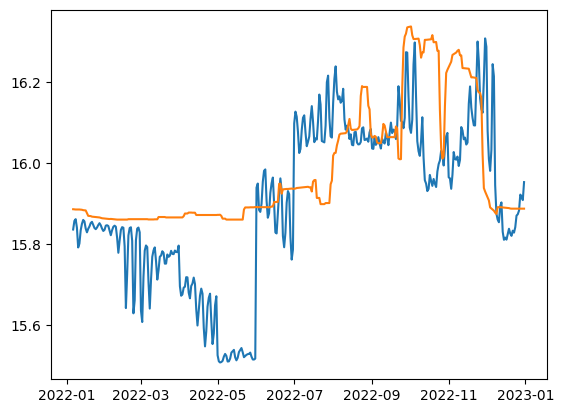

In [214]:
plot_forecast(y_test[:, 0], ground[:, 0])

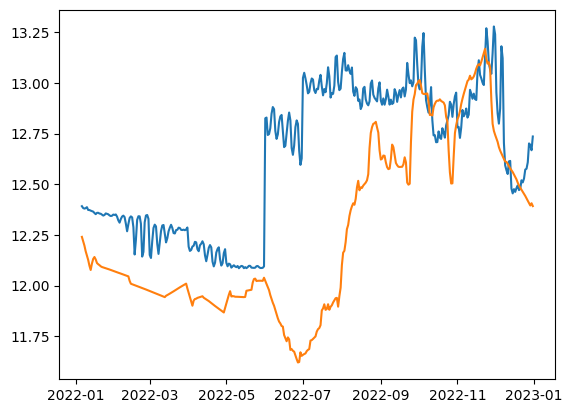

In [215]:
plot_forecast(y_test[:, 1], ground[:, 1])

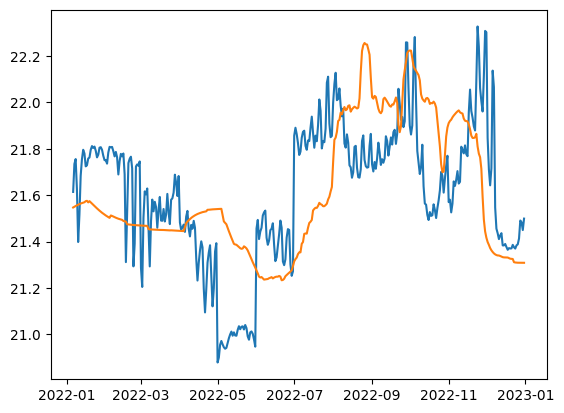

In [216]:
plot_forecast(y_test[:, 2], ground[:, 2])

#### Visualize Attention Scores

In [217]:
def plot_attention_head(attention):
    ax = plt.gca()
    
    # plot scores
    attention = attention[10:]
    attention = block_reduce(attention, (90, 90), np.mean)
    ax.matshow(attention)
    
    # plot labels
    dates = ['2021 Q1', '2021 Q2', '2021 Q3', '2021 Q4', '2022 Q1', '2022 Q2', '2022 Q3', '2022 Q4']
    ax.set_xticks(range(len(dates)))
    ax.set_yticks(range(len(dates)))

    ax.set_xticklabels(dates, rotation=90)
    ax.set_yticklabels(dates)
    plt.show()

In [218]:
attn_scores =  torch.squeeze(attn_scores, dim=0)
attn_scores = attn_scores.detach().cpu().numpy()
attn_scores.shape

(4, 730, 730)

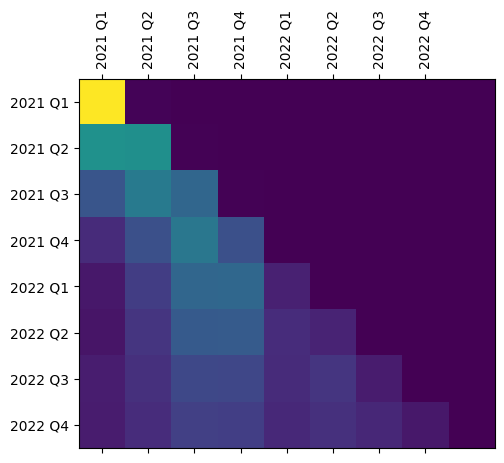

In [219]:
plot_attention_head(attn_scores[0])    

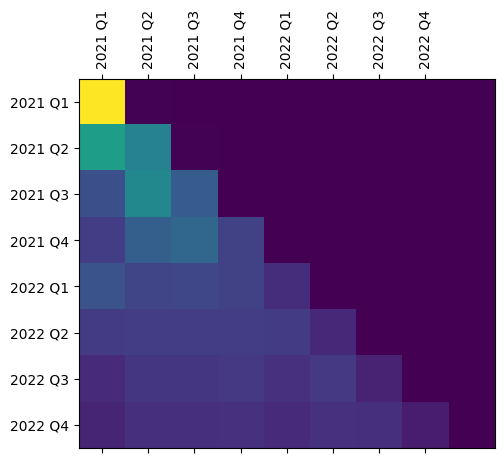

In [220]:
plot_attention_head(attn_scores[1])    

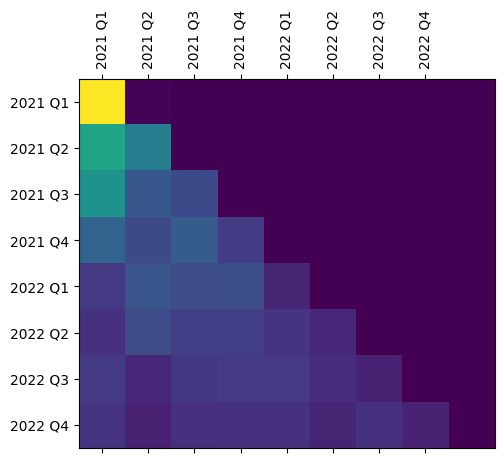

In [221]:
plot_attention_head(attn_scores[2])    

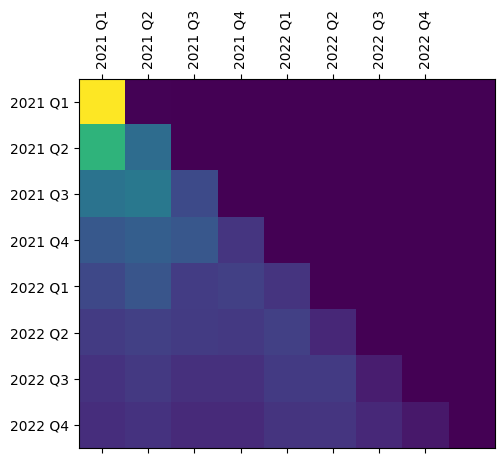

In [222]:
plot_attention_head(attn_scores[3])    

The heat maps represents the learned temporal relationships. The researchers observed that in forecasting future data, the model is focusing on either the previous weeks or the same week last year.